딥러닝 3일차 

In [1]:
!pip install scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import keras 
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [3]:
# 실행할 때마다 랜덤 값이 동일하게 나오고 싶으면, seed 지정할 것
keras.utils.set_random_seed(42)
tf.random.set_seed(42)
tf.config.experimental.enable_op_determinism()


In [4]:
(train_input, train_target), _ = \
    keras.datasets.fashion_mnist.load_data()
train_scaled = train_input / 255.0

In [5]:
train_scaled, val_scaled, train_target, val_target = \
    train_test_split(train_scaled, train_target,
                     test_size=0.2, random_state=42)

In [6]:
train_scaled.shape

(48000, 28, 28)

In [7]:
def model_fn(a_layer=None):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(28,28)))
    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dense(100, activation='relu')) #은닉층
    if a_layer:
        model.add(a_layer)
    model.add(keras.layers.Dense(10, activation='softmax'))
    return model

In [8]:
model = model_fn()
model.compile(loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [9]:
history = model.fit(
    train_scaled, train_target, epochs=20, verbose=0,
    validation_data=(val_scaled, val_target))

plt.plot(history.history['loss'],     label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend(); plt.show()

NameError: name 'plt' is not defined

In [ ]:
history.history

{'accuracy': [0.8112708330154419,
  0.8567916750907898,
  0.8702083230018616,
  0.8820624947547913,
  0.8872708082199097,
  0.8931249976158142,
  0.8975833058357239,
  0.9007499814033508,
  0.9041875004768372,
  0.9069374799728394,
  0.9095208048820496,
  0.9125833511352539,
  0.9149791598320007,
  0.9180833101272583,
  0.9198750257492065,
  0.9212499856948853,
  0.9234166741371155,
  0.9262499809265137,
  0.9269166588783264,
  0.9290416836738586],
 'loss': [0.5341317057609558,
  0.3936639428138733,
  0.35427993535995483,
  0.3314090669155121,
  0.31553277373313904,
  0.30334338545799255,
  0.29295313358306885,
  0.28309205174446106,
  0.27587854862213135,
  0.2682214379310608,
  0.26260706782341003,
  0.2542586326599121,
  0.24880503118038177,
  0.24310070276260376,
  0.2373483031988144,
  0.2348431646823883,
  0.2302074134349823,
  0.22622451186180115,
  0.2213747501373291,
  0.21688571572303772],
 'val_accuracy': [0.8484166860580444,
  0.8565000295639038,
  0.8620833158493042,
  0.8

In [ ]:
import matplotlib.pyplot as plt

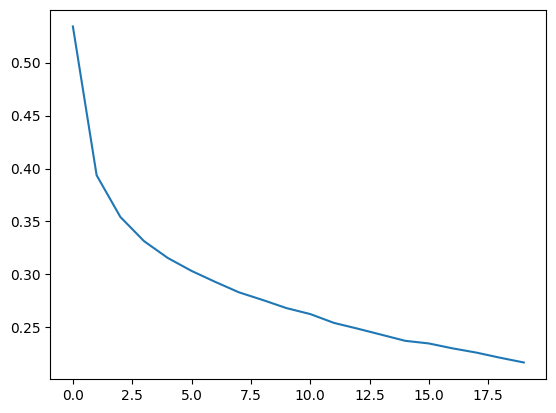

In [ ]:
plt.plot(history.history['loss'])

In [ ]:
model = model_fn()
model.compile(loss=keras.losses)
history = model.fit(
    train_scaled, train_target, epochs=20, verbose=0,
    validation_data=(val_scaled, val_target))

plt.plot(history.history['loss'],     label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend(); plt.show()

ValueError: Could not interpret loss identifier: <module 'keras.losses' from 'c:\\Users\\kim\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\keras\\losses\\__init__.py'>

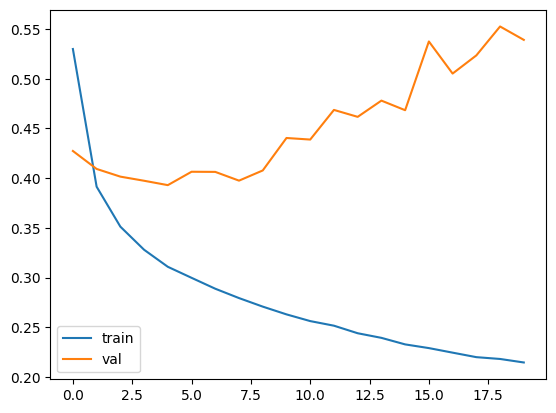

In [ ]:
# rmsprop 기본값
model = model_fn()
model.compile(loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(
    train_scaled, train_target, epochs=20, verbose=0,
    validation_data=(val_scaled, val_target))

plt.plot(history.history['loss'],     label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend(); plt.show()

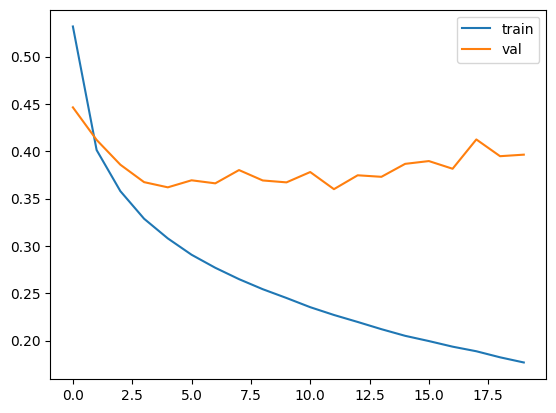

In [ ]:
# Adam
model = model_fn()
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(
    train_scaled, train_target, epochs=20, verbose=0,
    validation_data=(val_scaled, val_target))

plt.plot(history.history['loss'],     label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend(); plt.show()

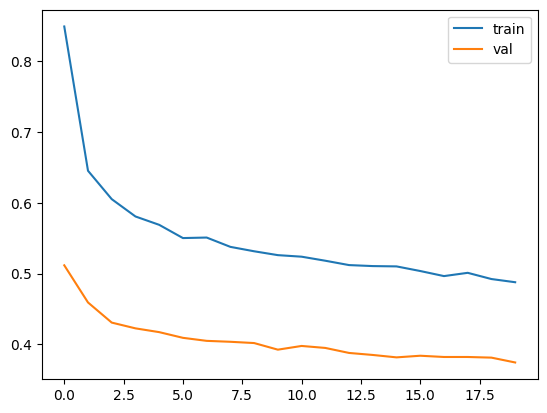

In [ ]:
# Dropout

model = model_fn(a_layer=keras.layers.Dropout(0.7)) #드롭 아웃층을 추가
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(
    train_scaled, train_target, epochs=20, verbose=0,
    validation_data=(val_scaled, val_target))

plt.plot(history.history['loss'],     label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend(); plt.show()

#Dropout은 뉴런을 끄는 연산만 하고, 가중치는 그대로이다.

In [ ]:
model.save('model-whole.keras')       # 구조+가중치
model.save_weights('model.weights.h5') # 가중치만

In [ ]:
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    'best-model.keras',
    save_best_only=True)   # val_loss 개선될 때만 저장

early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=2,                  # 2 epoch 개선 없으면 종료
    restore_best_weights=True)   # 최적 가중치 복원

history = model.fit(
    train_scaled, train_target, epochs=20, verbose=0,
    validation_data=(val_scaled, val_target),
    callbacks=[checkpoint_cb, early_stopping_cb])

print(early_stopping_cb.stopped_epoch)  # 12
model.evaluate(val_scaled, val_target)  # 0.8853

7
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 909us/step - accuracy: 0.8641 - loss: 0.3758


[0.375827431678772, 0.8640833497047424]

In [ ]:
#드롭아웃 외에도 정규화 방법 존재
# L2 정규화: 수학적해석 명확, 서규모 데이터셋에서 안정적으로 작동,랜덤오ㅛ소없음

model.add(keras.layers.Dense(100, activation='relu'))

In [ ]:
#저장
model.save('model.keras') #모델의 구조와 가중치 모두 저장, keras 형식으로 저장

In [ ]:
model.save_weights('model.weights.h5') #가중치만 저장, HDF5 형식으로 저장

모델 불러오기

In [ ]:
import tensorflow as tf
import keras

In [ ]:
model = keras.models.load_model('model.keras')
model

<Sequential name=sequential_19, built=True>

In [10]:
model2 = model_fn(keras.layers.Dropout(0.3))
model2.load_weights('model.weight.h5')

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'model.weight.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
# compile, fit 없어도 바로 예측 가능
model2.predict(val_scaled)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 712us/step


array([[0.16156429, 0.10665195, 0.1045244 , ..., 0.07806714, 0.1377109 ,
        0.10856122],
       [0.2301021 , 0.13005081, 0.04980114, ..., 0.0938316 , 0.12533332,
        0.07404744],
       [0.0839674 , 0.17544435, 0.05535491, ..., 0.09457393, 0.07482256,
        0.10512804],
       ...,
       [0.17557982, 0.12928127, 0.06329034, ..., 0.10429101, 0.09703017,
        0.12131844],
       [0.08472718, 0.1169985 , 0.21721129, ..., 0.07308477, 0.08928543,
        0.09848635],
       [0.07900864, 0.16617624, 0.09278868, ..., 0.08277402, 0.07594215,
        0.09832244]], shape=(12000, 10), dtype=float32)

In [13]:
model3 = keras.models.load_model('model.keras')
model3.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 914us/step - accuracy: 0.8641 - loss: 0.3758


[0.375827431678772, 0.8640833497047424]

## CallBack
학습(fit) 실행 중,특정 이벤트에 자동으로 동작하는 함수.


In [14]:
keras.callbacks.ModelCheckpoint('best-model.keras',
                                save_best_only=True) # 최적의 val_loss 개선될 때 저장


In [17]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target),
                    callbacks=[checkpoint]
                    ) #콜백 함수 추가

NameError: name 'checkpoint' is not defined

In [19]:
# 최적의 모델불러오기
model_best = keras.models.load_model('best-model.keras')

In [20]:
model_best.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 976us/step - accuracy: 0.8641 - loss: 0.3758


[0.375827431678772, 0.8640833497047424]

In [ ]:
## Early stopping

keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True, )

In [21]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target),
                    callbacks=[checkpoint, early_stopping]
                    ) #콜백 함수 추가

NameError: name 'checkpoint' is not defined

In [22]:
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    'best-model.keras',
    save_best_only=True)   # val_loss 개선될 때만 저장

early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=2,                  # 2 epoch 개선 없으면 종료
    restore_best_weights=True)   # 최적 가중치 복원

history = model.fit(
    train_scaled, train_target, epochs=20, verbose=0,
    validation_data=(val_scaled, val_target),
    callbacks=[checkpoint_cb, early_stopping_cb])

print(early_stopping_cb.stopped_epoch)  # 12
model.evaluate(val_scaled, val_target)  # 0.885

14
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 903us/step - accuracy: 0.8857 - loss: 0.3210


[0.32104283571243286, 0.8856666684150696]

In [23]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8857 - loss: 0.3210


[0.32104283571243286, 0.8856666684150696]

In [24]:
!uv pip install ucimlrepo

Resolved 7 packages in 386ms
 Downloaded pandas
Prepared 2 packages in 1.75s
Installed 3 packages in 302ms
 + pandas==3.0.3
 + tzdata==2026.2
 + ucimlrepo==0.0.7
